In [2]:
import sys
fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'
if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)
    
general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)


In [3]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

import os
import glob
import json
import numpy as np
#import tensorflow as tf
import sys

In [4]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample', 'old_cellCnn.model_grid' ]

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration

timepoints_elaboration rimosso dalla cache
results_elaboration non trovato nella cache
new_datasets_generation non trovato nella cache
run_models non trovato nella cache
old_cellCnn.model non trovato nella cache
old_cellCnn.utils non trovato nella cache
old_cellCnn.downsample non trovato nella cache
old_cellCnn.model_grid non trovato nella cache


In [5]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

Elaborating file 0: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220204-2900.csv
Elaborating file 1: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220208-3665.csv
Elaborating file 2: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_220216-3546.csv
Elaborating file 3: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 4: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 5: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 6: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 7: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 8: C:\Users\admin\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
Elaborating

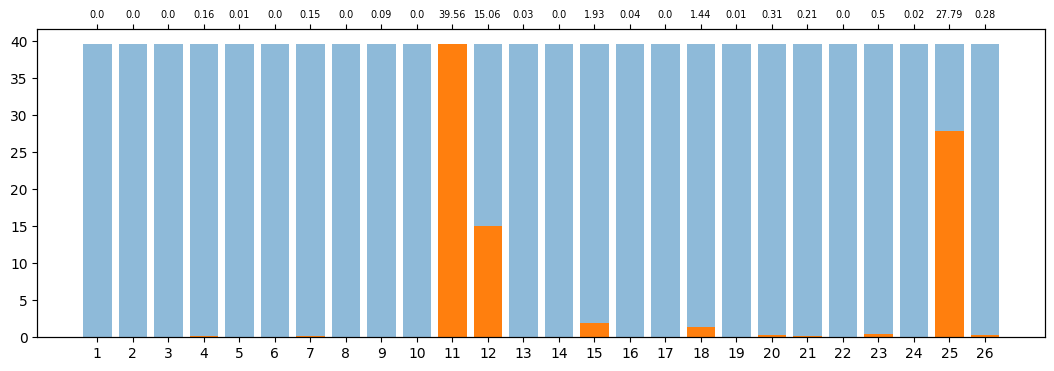

[6558750, 2764877, 1291729, 843500, 1404000, 3265250, 430869, 722000, 864000, 1947518, 778750, 5510750, 208000, 2912500, 160500, 3591480, 3107000, 637409, 2928000, 164553, 191975, 169000, 479000, 455000, 160828, 505000]
[0, 0, 0, 1348, 170, 0, 639, 15, 757, 0, 308059, 830101, 72, 0, 3096, 1449, 0, 9147, 227, 518, 398, 0, 2390, 77, 44697, 1413]


In [6]:
def show_blast_distribution(ALL_DATASETS, return_perc = False):
    tot_perc_list = []
    tot_blast_num_list = []
    for i, dataset in enumerate(ALL_DATASETS):
        blast_n = (dataset['IsBlast'] == 1).sum()
        tot_perc_list.append(round((blast_n/len(dataset))*100, 2))
        tot_blast_num_list.append(blast_n)
    positions = range(1, len(tot_perc_list) + 1)
    
    fig, ax1 = plt.subplots(figsize = [len(positions)/2,4])
    ax1.bar(list(range(1, len(tot_perc_list) + 1)), [max(tot_perc_list)]*len(tot_perc_list), alpha = 0.5)
    ax1.bar(list(range(1, len(tot_perc_list) + 1)), tot_perc_list)
    ax1.set_xticks(positions)
    
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(ax1.get_xticks()) # Positions [1, 2, 3, 4]
    
    ax2.set_xticklabels(tot_perc_list, size = 'x-small')
    plt.show()

    if return_perc:
        print([len(ds) for ds in ALL_DATASETS])
        return tot_perc_list, tot_blast_num_list
tot_perc_list, tot_blast_num_list = show_blast_distribution(ALL_DATASETS, return_perc = True)
print( tot_blast_num_list)

In [7]:
print(multiple_donations)

{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}


[0.16, 0.01, 0.0, 0.15, 0.0, 0.09, 0.0, 39.56, 15.06, 0.03, 0.0, 1.93, 0.04, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 0.5, 0.02, 27.79, 0.28, 0.0, 0.0, 0.0]
[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 0, 1, 2]
[11, 11, 11, 12, 12, 1, 1, 2, 2, 3, 3, 4, 4, 4, 6, 6, 7, 7, 7, 8, 8, 9, 9, 13, 14, 15]
[25  2 23  4  6 18 10 13 24  1 15 20  9 12  5  3  0 17 22 16 19 14 11  8
 21  7]
[0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 1.000e-02 1.000e-02 2.000e-02 3.000e-02 4.000e-02
 9.000e-02 1.500e-01 1.600e-01 2.100e-01 2.800e-01 3.100e-01 5.000e-01
 1.440e+00 1.930e+00 1.506e+01 2.779e+01 3.956e+01]


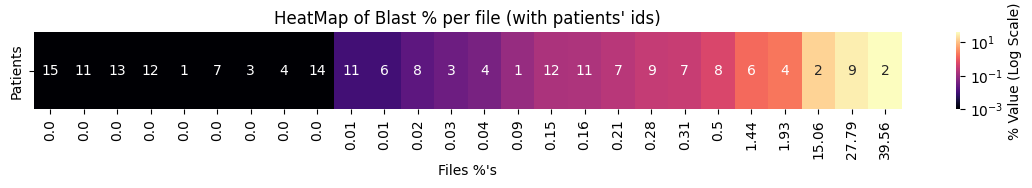

In [8]:
import seaborn as sns
from matplotlib.colors import LogNorm

def show_files_blast_distribution(tot_perc_list, multiple_donations, order_by = 'patient'):
    
    
    
    # retrieve the patients ids and files ids
    per_patient_timepoints = []
    timepoints_patients = []
    tot_perc = []
    for patient, files in multiple_donations.items():
        for file in files:
            tot_perc.append(tot_perc_list[file])
        per_patient_timepoints += [int(patient)]*len(files)
        timepoints_patients += list(files)

    print(tot_perc)
    print(timepoints_patients)
    print(per_patient_timepoints)
    
    #tot_perc_list = np.sort(tot_perc_list)
    if order_by == 'patient':
        order_idx = np.argsort(per_patient_timepoints)
    elif order_by == 'perc':
        order_idx = np.argsort(tot_perc)
        print(order_idx)
        print(np.array(tot_perc)[order_idx])
    else:
        order_idx = np.argsort(timepoints_patients)
        
    ordered_timepoints_patients = np.array(timepoints_patients)[order_idx]
    ordered_per_patient_timepoints = np.array(per_patient_timepoints)[order_idx]

    if order_by == 'perc':
        perc_df = pd.DataFrame(np.sort(tot_perc)).T
    else:
        perc_df = pd.DataFrame(np.array(tot_perc_list)[ordered_timepoints_patients]).T
    #df = pd.DataFrame([tot_perc_list, ordered_timepoints_patients, ordered_per_patient_timepoints] )
    #print(df)
    ordered_per_patient_timepoints = [str(patient) for patient in ordered_per_patient_timepoints]
    label_df = pd.DataFrame(ordered_per_patient_timepoints).T
    #print(len(label_df), len(perc_df))
    perc_df = perc_df.replace(0, 10**-3)
    
    perc_df.index = ['Patients']
    label_df.index = ['Patients']
    
    data_min = np.nanmin(perc_df.values)
    data_max = np.nanmax(perc_df.values)
        
    log_vmin = 10**(-3) if data_min <= 0 else data_min
    if data_max <= log_vmin:
            log_vmax = log_vmin * 10**(-3)
            print(f"⚠️ Warning: data_max ({data_max}) too close to vmin. Adjusted vmax to {log_vmax}.")
    else:
            log_vmax = data_max
    log_norm = LogNorm(vmin=log_vmin, vmax=log_vmax) # Usa log_vmax
    
    plt.figure(figsize= (14,1))
    ax = sns.heatmap(data = perc_df,
                annot = label_df ,
                cmap = 'magma',
                cbar = True,
                fmt = 's',
                norm=log_norm,
                #cbar=cbar, # <--- Usa il parametro cbar
                cbar_kws={'label': '% Value (Log Scale)'}
                    )
    #ax2 = ax.twiny()
    #ax2.set_xticks(ax.get_xticks())
    if order_by == 'perc':
        ax.set_xticklabels(np.sort(tot_perc), rotation=90)
    else:
        ax.set_xticklabels(np.array(tot_perc_list)[ordered_timepoints_patients], rotation=90)
    plt.xlabel("Files %'s")
    plt.title("HeatMap of Blast % per file (with patients' ids)")
    plt.show()

show_files_blast_distribution(tot_perc_list, multiple_donations, 'perc')

In [9]:
train_donors_idx = ['3', '15', '6', '7', '9']
val_donors_idx = ['13', '12']
test_donors_idx = ['2', '8', '14', '11', '1', '4']
all_files = train_donors_idx + val_donors_idx + test_donors_idx
cv_train_val = train_donors_idx + val_donors_idx
print(cv_train_val)

['3', '15', '6', '7', '9', '13', '12']



data_min: 0


data_max: 830101



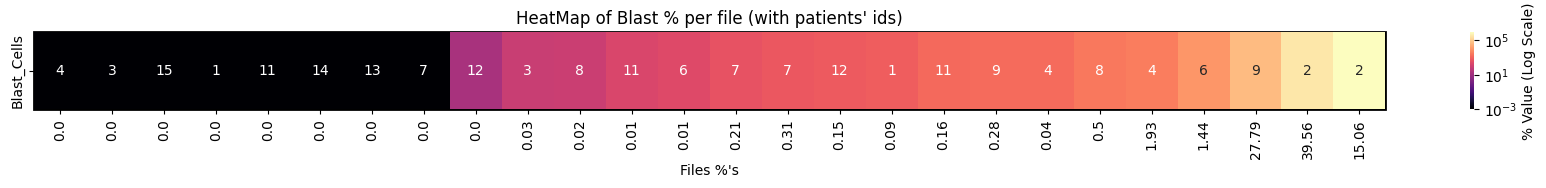


data_min: 0


data_max: 830101



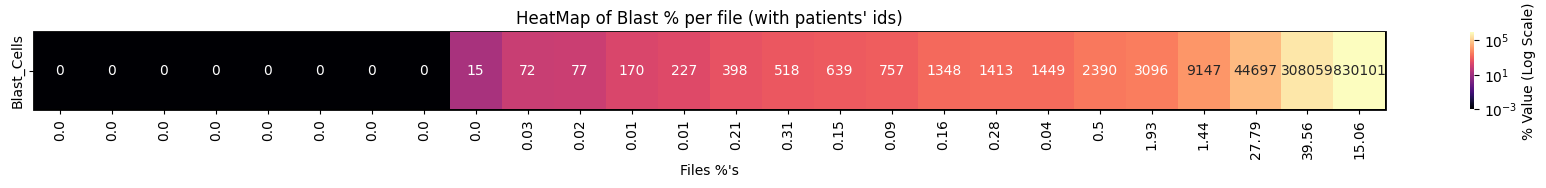


data_min: 0


data_max: 830101



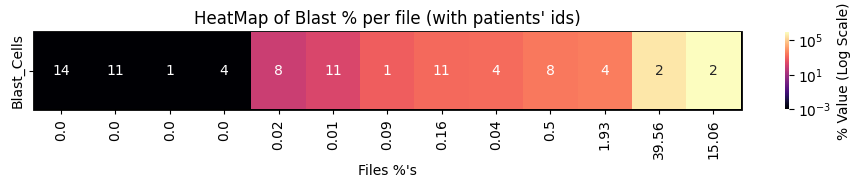


data_min: 0


data_max: 830101



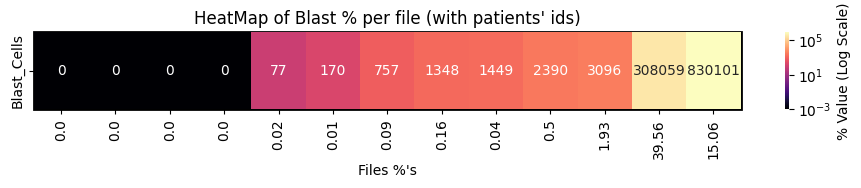


data_min: 0


data_max: 830101



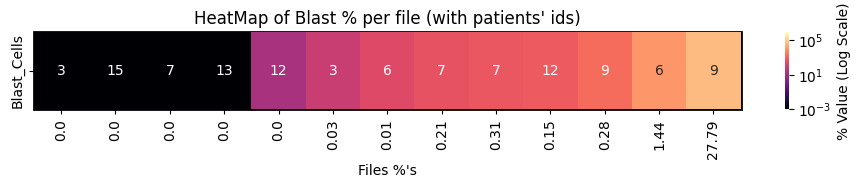


data_min: 0


data_max: 830101



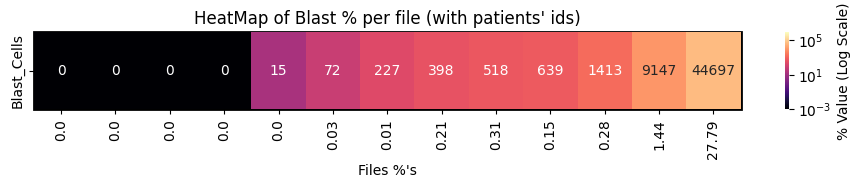

In [42]:
def show_splitted_patients_distribution(test_donors_idx, multiple_donations, order_by = 'perc', tot_blast_num_list = None, label = None):
    test_mult_don = []
    test_blast_perc = []
    blast_num_list = []
    for patient in test_donors_idx:
        test_mult_don += [patient] * len(multiple_donations[patient])
        for file in multiple_donations[patient]:
            test_blast_perc.append(tot_perc_list[file])
            
            if tot_blast_num_list is not None:
                blast_num_list.append(tot_blast_num_list[file])
    

    for i in range(1):
        if order_by == 'perc':
            order_idx = np.argsort(test_blast_perc)
            perc_df = pd.DataFrame(np.array(test_blast_perc)[order_idx]).T
            label_df = pd.DataFrame(np.array(test_mult_don)[order_idx]).T

        else:
            perc_df = pd.DataFrame(test_blast_perc).T
            label_df = pd.DataFrame(test_mult_don).T
            
        perc_df.index = ['Patients']
        label_df.index = ['Patients']
        
        perc_df = perc_df.replace(0, 10**-3)
        data_min = np.nanmin(perc_df.values)
        data_max = np.nanmax(perc_df.values)
        
        if tot_blast_num_list is not None:
            order_idx = np.argsort(blast_num_list)
            perc_df = pd.DataFrame(np.array(blast_num_list)[order_idx]).T
            if label == 'patient':
                label_df = pd.DataFrame(np.array(test_mult_don)[order_idx]).T
            else:
                label_df = pd.DataFrame(np.array(blast_num_list)[order_idx]).T
            
            perc_df.index = ['Blast_Cells']
            label_df.index = ['Blast_Cells']
            perc_df = perc_df.replace(0, 10**-3)
            data_min = np.nanmin(tot_blast_num_list)
            data_max = np.nanmax(tot_blast_num_list)
            print(f'\ndata_min: {data_min}\n')
            print(f'\ndata_max: {data_max}\n')

            
        log_vmin = 10**(-3) if data_min <= 0 else data_min
        if data_max <= log_vmin:
                log_vmax = log_vmin * 10**(-3)
                print(f"⚠️ Warning: data_max ({data_max}) too close to vmin. Adjusted vmax to {log_vmax}.")
        else:
                log_vmax = data_max
        log_norm = LogNorm(vmin=log_vmin, vmax=data_max) # Usa log_vmax
        
        plt.figure(figsize= (0.8*len(test_blast_perc) + 1,1))
        ax = sns.heatmap(data = perc_df,
                    annot = label_df ,
                    #cmap = "YlOrBr",
                    cmap = 'magma',
                    #cmap = "coolwarm",
                    cbar = True,
                    fmt = '',
                    norm=log_norm,
                    #cbar=cbar, # <--- Usa il parametro cbar
                    cbar_kws={'label': '% Value (Log Scale)'}
                        )
        
        # Add a black border around the entire heatmap
        ax.patch.set_edgecolor('black')  
        ax.patch.set_linewidth(2)        # Adjust thickness as needed
        #ax2 = ax.twiny()
        #ax2.set_xticks(ax.get_xticks())
        if order_by == 'perc':
            ax.set_xticklabels(np.array(test_blast_perc)[order_idx], rotation=90)
        else:
            ax.set_xticklabels(test_blast_perc, rotation=90)
        plt.title("HeatMap of Blast % per file (with patients' ids)")
        plt.xlabel("Files %'s")
        plt.show()

#show_splitted_patients_distribution(train_donors_idx, multiple_donations, tot_blast_num_list = tot_blast_num_list)
#show_splitted_patients_distribution(val_donors_idx, multiple_donations, tot_blast_num_list = tot_blast_num_list)
show_splitted_patients_distribution(all_files, multiple_donations, tot_blast_num_list = tot_blast_num_list, label = 'patient')
show_splitted_patients_distribution(all_files, multiple_donations, tot_blast_num_list = tot_blast_num_list)
show_splitted_patients_distribution(test_donors_idx, multiple_donations, tot_blast_num_list = tot_blast_num_list, label = 'patient')
show_splitted_patients_distribution(test_donors_idx, multiple_donations, tot_blast_num_list = tot_blast_num_list)
show_splitted_patients_distribution(cv_train_val, multiple_donations, tot_blast_num_list = tot_blast_num_list, label = 'patient')
show_splitted_patients_distribution(cv_train_val, multiple_donations, tot_blast_num_list = tot_blast_num_list)


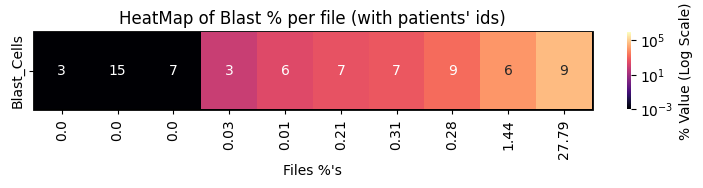

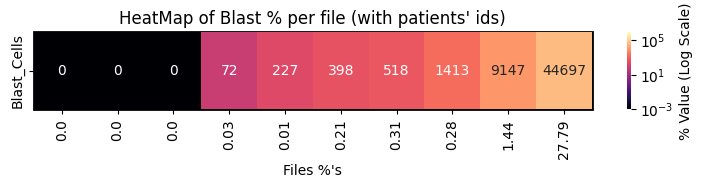

In [11]:
train_fold, val_fold = ['3', '15', '6', '7', '9'], ['13', '12']

show_splitted_patients_distribution(train_fold, multiple_donations, tot_blast_num_list = tot_blast_num_list, label = 'patient')
show_splitted_patients_distribution(train_fold, multiple_donations, tot_blast_num_list = tot_blast_num_list)

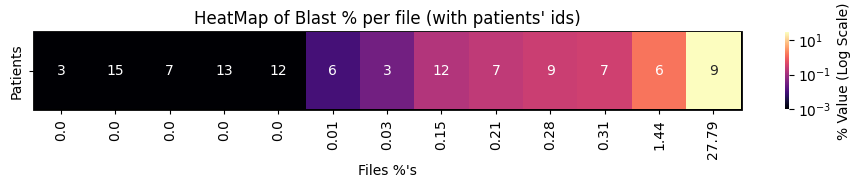

In [12]:
show_splitted_patients_distribution(cv_train_val , multiple_donations)

In [14]:
# classical CV 3 fold
def classic_CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx, folds = 3):
    h_pat, b_pat, m_pat = healthy_donors.copy(), blast_donors.copy(), mixed_donors.copy()

    tot_pat = []
    for pat in test_donors_idx:
        if pat in healthy_donors:
            h_pat.remove(pat)
        if pat in blast_donors:
             b_pat.remove(pat)
        if pat in mixed_donors:
            m_pat.remove(pat)

    from itertools import zip_longest
    
    tot_pat = []
    for pat_1, pat_2, pat_3 in zip_longest(h_pat, b_pat, m_pat, fillvalue=None):
        # Only add non-None values (or whatever fillvalue you choose)
        if pat_1 is not None:
            tot_pat.append(pat_1)
        if pat_2 is not None:
            tot_pat.append(pat_2)
        if pat_3 is not None:
            tot_pat.append(pat_3)
    
    print(h_pat, b_pat, m_pat)
    print(tot_pat)


    sub_len = int(len(tot_pat)/folds)
    print(sub_len)
    single_folds = []
    counter = 0
    for fold in range(folds - 1):
        print(fold)
        single_folds.append(tot_pat[counter: counter + sub_len])
        counter += sub_len
    single_folds.append(tot_pat[counter:])
    print(single_folds)

    tot_folds = []
    
    for n_fold in range(folds):
        val_fold = single_folds[n_fold - 1]
        train_fold = []
        for fold in single_folds:
            if fold != val_fold:
                train_fold += fold
        print(train_fold, val_fold)
        tot_folds.append([train_fold, val_fold])
    return tot_folds
healthy_donors, blast_donors, mixed_donors = donor_division(multiple_donations, ALL_DATASETS)

chosen_perm = classic_CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx, folds = 3)

{'11': [1, 1, 0], '12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1], '13': [0], '14': [0], '15': [0]}
['13', '15'] ['12', '6', '9'] ['3', '7']
['13', '12', '3', '15', '6', '7', '9']
2
0
1
[['13', '12'], ['3', '15'], ['6', '7', '9']]
['13', '12', '3', '15'] ['6', '7', '9']
['3', '15', '6', '7', '9'] ['13', '12']
['13', '12', '6', '7', '9'] ['3', '15']


In [15]:
print(multiple_donations) 

fold_features = {}
for i, (train_set, val_set) in enumerate(chosen_perm):
    #print(train_set, val_set)

    set_train_files, set_val_files = [], []
    for train_pat in train_set:
        train_files = multiple_donations[train_pat]
        set_train_files += train_files

    train_file_perc = list(np.array(tot_perc_list)[set_train_files])
    train_features = [train_set, train_file_perc, np.mean(train_file_perc), np.std(train_file_perc)]
    #print(train_features)
    
    for val_pat in val_set:
        val_files = multiple_donations[val_pat]
        set_val_files += val_files

    val_file_perc = list(np.array(tot_perc_list)[set_val_files])
    val_features = [val_set, val_file_perc, np.mean(val_file_perc), np.std(val_file_perc)]
    #print(val_features)
    
    fold_features[i] = [train_features, val_features]
    
    #print(set_train_files, set_val_files)
    print(train_file_perc, val_file_perc)


for fold, (train_features, val_features) in fold_features.items():
    #if int(fold) < 3 or int(fold) == 4:
        train_donors_idx, val_donors_idx = train_features[0], val_features[0]
        
        print(f'Train: {train_features}')
        print(f'Val: {val_features}\n')
    



{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}
[0.0, 0.15, 0.0, 0.03, 0.0, 0.0] [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28]
[0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28] [0.0, 0.15, 0.0]
[0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28] [0.03, 0.0, 0.0]
Train: [['13', '12', '3', '15'], [0.0, 0.15, 0.0, 0.03, 0.0, 0.0], 0.03, 0.05477225575051661]
Val: [['6', '7', '9'], [1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 4.291428571428571, 9.60403104143765]

Train: [['3', '15', '6', '7', '9'], [0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.007, 8.27137721301598]
Val: [['13', '12'], [0.0, 0.15, 0.0], 0.049999999999999996, 0.07071067811865475]

Train: [['13', '12', '6', '7', '9'], [0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28], 3.019, 8.267135477298046]
Val: [['3', '15'], [0.03, 0.0, 0.0], 0.01, 0.01414213562

In [16]:
print(train_labels)
print(fold_features)
print(train_labels)

NameError: name 'train_labels' is not defined

[0.0, 0.31, 0.21, 0.0, 1.44, 0.01, 27.79, 0.28] [13, 7, 7, 7, 6, 6, 9, 9]
num_list: [0, 518, 398, 0, 9147, 227, 44697, 1413]
num_list_ordered: [    0     0   227   398   518  1413  9147 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 1.000e-02 2.100e-01 3.100e-01 2.800e-01 1.440e+00
 2.779e+01]
[0.0, 0.03, 0.0, 1.44, 0.01, 27.79, 0.28] [15, 3, 3, 6, 6, 9, 9]
num_list: [0, 72, 0, 9147, 227, 44697, 1413]
num_list_ordered: [    0     0    72   227  1413  9147 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697], [0, 0, 72, 227, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 3.000e-02 1.000e-02 2.800e-01 1.440e+00 2.779e+01]
[0.0, 0.03, 0.0, 0.15, 0.0, 27.79, 0.28] [15, 3, 3, 12, 12, 9, 9]
num_list: [0, 72, 0, 639, 15, 44697, 1413]
num_list_ordered: [    0     0    15    72   639  1413 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697], [0, 0, 72, 227, 1413, 9147, 44697], [0, 0, 15, 72, 639, 1413, 44697]]
[ 0.    0.    0.    0.03  0.15  0.28 27.79]
[0.0, 0.03, 0.0, 1.44, 0.01, 2

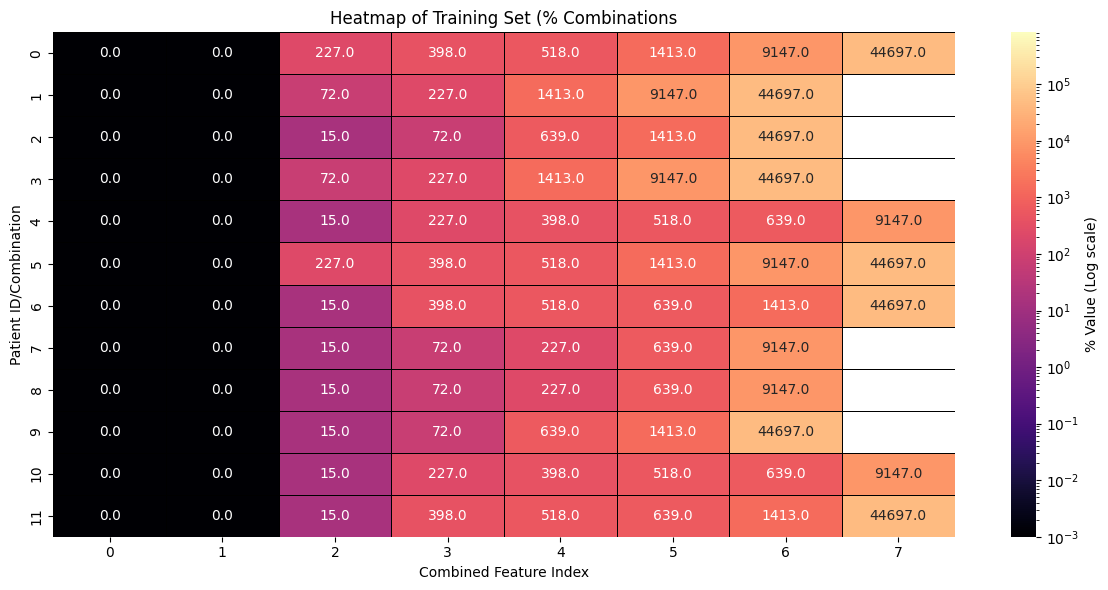

In [68]:
import seaborn as sns
from matplotlib.colors import LogNorm

train_heat, val_heat = [], []
train_labels, val_labels = [], []
for fold, (train_f, val_f) in fold_features.items():
    #print(train_f, val_f)
    
    train_heat.append(train_f[1])
    train_labels.append(train_f[0])
    val_heat.append(val_f[1])
    val_labels.append(val_f[0])

def heatmap_fold(train_heat, train_labels, multiple_donations, ax = None, cbar=True, fold = 'train', tot_blast_num_list = None ):
    if fold == 'train':
        fold_text = 'Training'
    elif fold == 'valid':
        fold_text = 'Validation'
        
    patient_heat = [] 
    patient_labels = []
    blast_num_list = []
    for heat, label in zip(train_heat, train_labels):
        
        labels = []
        for idx in label:
             labels += [int(idx)]*len(multiple_donations[idx])
        print(heat, labels)

        if tot_blast_num_list is not None:
            
            num_list = []
            for patient in label:
                files = multiple_donations[patient]
                for file in files:
                    num_list.append(tot_blast_num_list[file])
                
            print(f'num_list: {num_list}')
            order_idx = np.argsort(num_list)

            
            print(f'num_list_ordered: {np.array(num_list)[order_idx]}')
            blast_num_list.append(list(np.array(num_list)[order_idx]))
            print(blast_num_list)

                
        else:
            order_idx = np.argsort(heat)
            
        print(np.array(heat)[order_idx])
        patient_heat.append(np.array(heat)[order_idx])
        patient_labels.append(np.array(labels)[order_idx])



    # Convert the list of lists into a DataFrame
    train_heat_df = pd.DataFrame(patient_heat)
    train_labels_df = pd.DataFrame(patient_labels)
            
    
            
    #print(f'train_heat_df: {train_heat_df}')
    train_heat_df.index = [f'Combin. {i+1}' for i in range(len(train_heat_df))]
    train_labels_df.index = [f'Combin. {i+1}' for i in range(len(train_labels_df))]
    # 🌟 CORREZIONE: Calcolo di vmin e LogNorm con gestione dello zero
    
    data_min = np.nanmin(train_heat_df.values)
    data_max = np.nanmax(train_heat_df.values)

    if tot_blast_num_list is not None:
        # Convert the list of lists into a DataFrame
        #str(num) for num in
        #blast_num_list = [ str(num) for fold in blast_num_list for num in fold]
        train_heat_df = pd.DataFrame(blast_num_list)
        #train_labels_df = pd.DataFrame(patient_labels)
        
        print('')
        print(train_labels_df)
        #blast_num_list = [ str(num) for num in fold or fold in blast_num_list]
        train_labels_df = pd.DataFrame(blast_num_list)
        
        
        print(train_labels_df)
        print( train_heat_df)
        print('')
    
        #perc_df = perc_df.replace(0, 10**-3)
        data_min = np.nanmin(tot_blast_num_list)
        data_max = np.nanmax(tot_blast_num_list)
        print(f'\ndata_min: {data_min}\n')
        print(f'\ndata_max: {data_max}\n')
        
    # Se il minimo è 0, o negativo, usa un valore positivo molto piccolo (epsilon)
    # in modo che LogNorm possa funzionare.
    train_heat_df= train_heat_df.replace(0, 10**(-3))
    if data_min <= 0:
        log_vmin = 10**(-3)
        print(f"⚠️ Warning: Minimum data value is {data_min}. Setting LogNorm vmin to {log_vmin} to avoid log(0) error.")
    else:
        log_vmin = data_min
   # print(f'data_min: {data_min}')
    # Crea l'oggetto LogNorm con i valori positivi e finiti
    
    log_norm = LogNorm(vmin=log_vmin, vmax=data_max)
    
    if ax is None:
        plt.figure(figsize=(12, 6))
        ax = sns.heatmap(
            train_heat_df,
            annot=train_labels_df, # Annotation is now set to True
            #annot = True,
            #mt=".2f",  # Format the percentage values to 2 decimal places
            fmt="" ,               # Usiamo una stringa vuota dato che le annotazioni sono int
            cmap='magma',
            norm=log_norm,        # ⭐ PARAMETRO FONDAMENTALE! Applica la normalizzazione logaritmica.
            cbar_kws={'label': '% Value (Log scale)'},
            #cbar_kws={'label': 'Percentage Value'},
            cbar=cbar,
            linewidths=.5,
            linecolor='black'
        )
    
        if fold == 'train':
            fold_text = 'Training'
        elif fold == 'valid':
            fold_text = 'Validation'
        plt.title(f'Heatmap of {fold_text} Set (% Combinations')
        plt.ylabel('Patient ID/Combination')
        plt.xlabel('Combined Feature Index')
        
        plt.tight_layout()

    else:
        sns.heatmap(
            train_heat_df,
            annot=train_labels_df, # Annotation is now set to True
            ax=ax,
            #annot = True,
            #fmt=".2f",  # Format the percentage values to 2 decimal places
            fmt="",               # Usiamo una stringa vuota dato che le annotazioni sono int
            cmap='magma',
            norm=log_norm,        # ⭐ PARAMETRO FONDAMENTALE! Applica la normalizzazione logaritmica.
            cbar_kws={'label': '% Value (Log scale)'},
            cbar=cbar,
            #cbar_kws={'label': 'Percentage Value'},
            linewidths=.5,
            linecolor='black',
            annot_kws = {'fontsize': 10}
        )
    
        if fold == 'train':
            fold_text = 'Training'
        elif fold == 'valid':
            fold_text = 'Validation'
        ax.set_title(f'Heatmap of {fold_text} Set (% Combinations)')
        ax.set_ylabel('Patient ID/Combination')
        ax.set_xlabel('Combined Feature Index')

heatmap_fold(train_heat, train_labels, multiple_donations, tot_blast_num_list= tot_blast_num_list)
#heatmap_fold(val_heat, val_labels, multiple_donations, fold = 'valid')

[0.0, 0.15, 0.0, 0.03, 0.0, 0.0] [13, 12, 12, 3, 3, 15]
num_list: [0, 639, 15, 72, 0, 0]
num_list_ordered: [  0   0   0  15  72 639]
[[0, 0, 0, 15, 72, 639]]
[0.   0.   0.   0.   0.03 0.15]
[0.03, 0.0, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28] [3, 3, 15, 6, 6, 7, 7, 7, 9, 9]
num_list: [72, 0, 0, 9147, 227, 518, 398, 0, 44697, 1413]
num_list_ordered: [    0     0     0    72   227   398   518  1413  9147 44697]
[[0, 0, 0, 15, 72, 639], [0, 0, 0, 72, 227, 398, 518, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 0.000e+00 3.000e-02 1.000e-02 2.100e-01 3.100e-01
 2.800e-01 1.440e+00 2.779e+01]
[0.0, 0.15, 0.0, 1.44, 0.01, 0.31, 0.21, 0.0, 27.79, 0.28] [13, 12, 12, 6, 6, 7, 7, 7, 9, 9]
num_list: [0, 639, 15, 9147, 227, 518, 398, 0, 44697, 1413]
num_list_ordered: [    0     0    15   227   398   518   639  1413  9147 44697]
[[0, 0, 0, 15, 72, 639], [0, 0, 0, 72, 227, 398, 518, 1413, 9147, 44697], [0, 0, 15, 227, 398, 518, 639, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 0.000e+00 1.000e-02 2.100

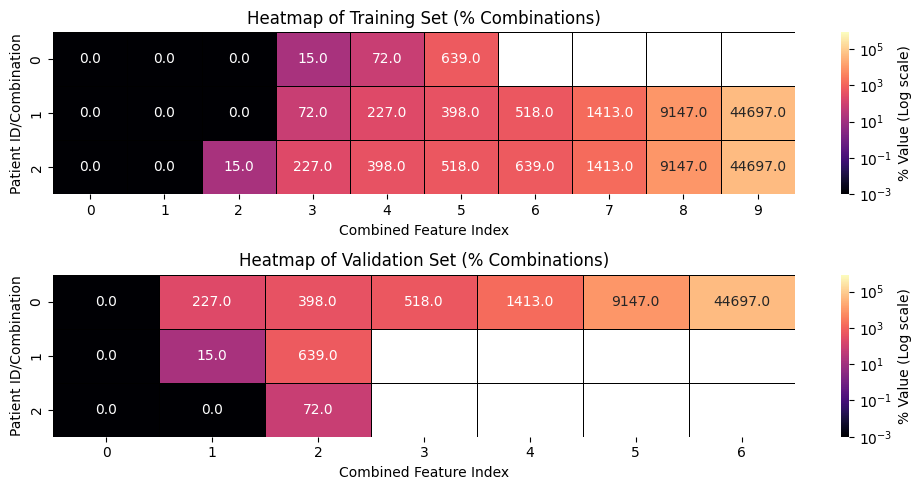

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

heatmap_fold(train_heat, train_labels, multiple_donations, ax = ax1, tot_blast_num_list = tot_blast_num_list)
heatmap_fold(val_heat, val_labels, multiple_donations, ax = ax2, fold = 'valid', tot_blast_num_list = tot_blast_num_list)
# Opzionale: Regola gli spazi tra i subplot per evitare sovrapposizioni
plt.tight_layout()
#plt.savefig('a')
# Mostra la figura unica
plt.show()


In [49]:
seed = 106519
def CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx):
    h_pat, b_pat, m_pat = healthy_donors.copy(), blast_donors.copy(), mixed_donors.copy()
    
    for pat in test_donors_idx:
        if pat in healthy_donors:
            h_pat.remove(pat)
        if pat in blast_donors:
             b_pat.remove(pat)
        if pat in mixed_donors:
            m_pat.remove(pat)
    
    #print(h_pat, b_pat, m_pat)
    
    train_perm = []
    for hp in h_pat:
        for mp in m_pat:
            train_perm.append([hp, mp, b_pat[0], b_pat[1]])
            train_perm.append([hp, mp, b_pat[0], b_pat[2]])
            train_perm.append([hp, mp, b_pat[1], b_pat[2]])
    
    tot_train_val_perm = h_pat + b_pat + m_pat
    val_perm = []
    for element in train_perm:
        q = set(tot_train_val_perm.copy()) - set(element)
        val_perm.append(list(q))
    
    for t_fold, v_fold in zip(train_perm, val_perm):
        print(t_fold, v_fold)
    return train_perm, val_perm

def choose_folds(iterations, train_perm, val_perm, seed = 42):
    print(seed)
    np.random.seed(seed)
    tot_perm = len(train_perm)
    
    idx = np.arange(tot_perm)
    np.random.shuffle(idx)

    chosen_folds = []
    for index in idx[:iterations]:
        chosen_folds.append([train_perm[index], val_perm[index]])
    
    return chosen_folds



In [50]:
# splits patients in categoties
healthy_donors, blast_donors, mixed_donors = donor_division(multiple_donations, ALL_DATASETS)


train_perm, val_perm = CV_train_val_splits(healthy_donors, blast_donors, mixed_donors, test_donors_idx)

iterations = 12
chosen_perm = choose_folds(iterations, train_perm, val_perm, seed)

{'11': [1, 1, 0], '12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1], '13': [0], '14': [0], '15': [0]}
['13', '3', '12', '6'] ['7', '9', '15']
['13', '3', '12', '9'] ['7', '6', '15']
['13', '3', '6', '9'] ['7', '12', '15']
['13', '7', '12', '6'] ['9', '3', '15']
['13', '7', '12', '9'] ['3', '6', '15']
['13', '7', '6', '9'] ['12', '3', '15']
['15', '3', '12', '6'] ['7', '13', '9']
['15', '3', '12', '9'] ['7', '13', '6']
['15', '3', '6', '9'] ['7', '12', '13']
['15', '7', '12', '6'] ['3', '13', '9']
['15', '7', '12', '9'] ['3', '13', '6']
['15', '7', '6', '9'] ['3', '12', '13']
106519


In [51]:
print(multiple_donations) 

fold_features = {}
for i, (train_set, val_set) in enumerate(chosen_perm):
    #print(train_set, val_set)

    set_train_files, set_val_files = [], []
    for train_pat in train_set:
        train_files = multiple_donations[train_pat]
        set_train_files += train_files

    train_file_perc = list(np.array(tot_perc_list)[set_train_files])
    train_features = [train_set, train_file_perc, np.mean(train_file_perc), np.std(train_file_perc)]
    #print(train_features)
    
    for val_pat in val_set:
        val_files = multiple_donations[val_pat]
        set_val_files += val_files

    val_file_perc = list(np.array(tot_perc_list)[set_val_files])
    val_features = [val_set, val_file_perc, np.mean(val_file_perc), np.std(val_file_perc)]
    #print(val_features)
    
    fold_features[i] = [train_features, val_features]
    
    #print(set_train_files, set_val_files)
    print(train_file_perc, val_file_perc)


for fold, (train_features, val_features) in fold_features.items():
    #if int(fold) < 3 or int(fold) == 4:
        train_donors_idx, val_donors_idx = train_features[0], val_features[0]
        
        print(f'Train: {train_features}')
        print(f'Val: {val_features}\n')
    



{'11': [3, 4, 5], '12': [6, 7], '1': [8, 9], '2': [10, 11], '3': [12, 13], '4': [14, 15, 16], '6': [17, 18], '7': [19, 20, 21], '8': [22, 23], '9': [24, 25], '13': [0], '14': [1], '15': [2]}
[0.0, 0.31, 0.21, 0.0, 1.44, 0.01, 27.79, 0.28] [0.15, 0.0, 0.03, 0.0, 0.0]
[0.0, 0.03, 0.0, 1.44, 0.01, 27.79, 0.28] [0.31, 0.21, 0.0, 0.15, 0.0, 0.0]
[0.0, 0.03, 0.0, 0.15, 0.0, 27.79, 0.28] [0.31, 0.21, 0.0, 0.0, 1.44, 0.01]
[0.0, 0.03, 0.0, 1.44, 0.01, 27.79, 0.28] [0.31, 0.21, 0.0, 0.15, 0.0, 0.0]
[0.0, 0.31, 0.21, 0.0, 0.15, 0.0, 1.44, 0.01] [0.03, 0.0, 0.0, 27.79, 0.28]
[0.0, 0.31, 0.21, 0.0, 1.44, 0.01, 27.79, 0.28] [0.03, 0.0, 0.15, 0.0, 0.0]
[0.0, 0.31, 0.21, 0.0, 0.15, 0.0, 27.79, 0.28] [0.03, 0.0, 0.0, 1.44, 0.01]
[0.0, 0.03, 0.0, 0.15, 0.0, 1.44, 0.01] [0.31, 0.21, 0.0, 27.79, 0.28, 0.0]
[0.0, 0.03, 0.0, 0.15, 0.0, 1.44, 0.01] [0.31, 0.21, 0.0, 0.0, 27.79, 0.28]
[0.0, 0.03, 0.0, 0.15, 0.0, 27.79, 0.28] [0.31, 0.21, 0.0, 1.44, 0.01, 0.0]
[0.0, 0.31, 0.21, 0.0, 0.15, 0.0, 1.44, 0.01] [27

[0.0, 0.31, 0.21, 0.0, 1.44, 0.01, 27.79, 0.28] [13, 7, 7, 7, 6, 6, 9, 9]
num_list: [0, 518, 398, 0, 9147, 227, 44697, 1413]
num_list_ordered: [    0     0   227   398   518  1413  9147 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 1.000e-02 2.100e-01 3.100e-01 2.800e-01 1.440e+00
 2.779e+01]
[0.0, 0.03, 0.0, 1.44, 0.01, 27.79, 0.28] [15, 3, 3, 6, 6, 9, 9]
num_list: [0, 72, 0, 9147, 227, 44697, 1413]
num_list_ordered: [    0     0    72   227  1413  9147 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697], [0, 0, 72, 227, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 3.000e-02 1.000e-02 2.800e-01 1.440e+00 2.779e+01]
[0.0, 0.03, 0.0, 0.15, 0.0, 27.79, 0.28] [15, 3, 3, 12, 12, 9, 9]
num_list: [0, 72, 0, 639, 15, 44697, 1413]
num_list_ordered: [    0     0    15    72   639  1413 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697], [0, 0, 72, 227, 1413, 9147, 44697], [0, 0, 15, 72, 639, 1413, 44697]]
[ 0.    0.    0.    0.03  0.15  0.28 27.79]
[0.0, 0.03, 0.0, 1.44, 0.01, 2

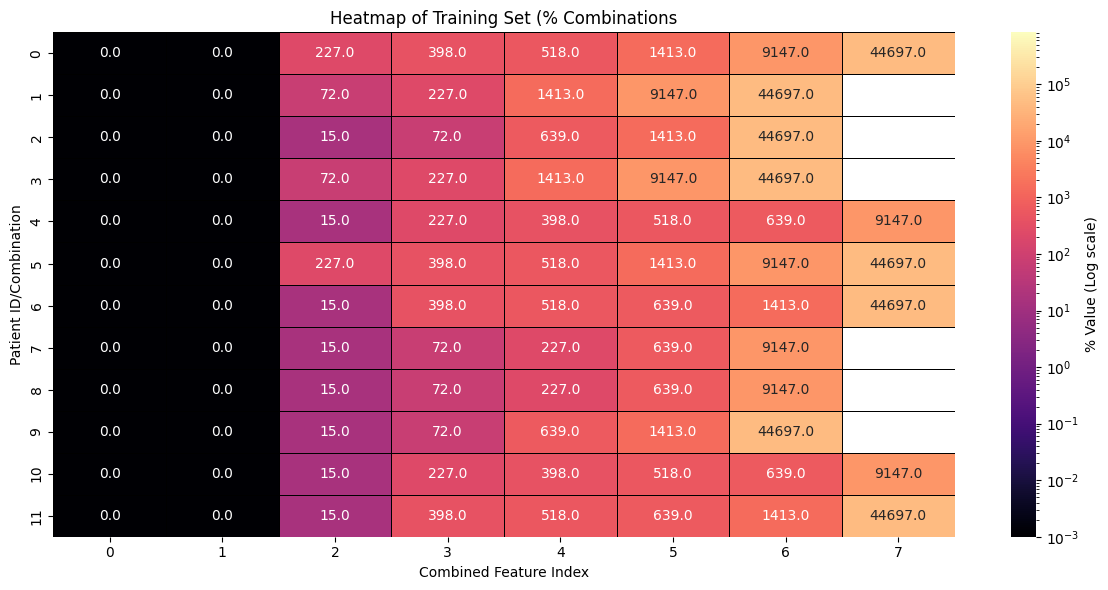

In [72]:
import seaborn as sns
from matplotlib.colors import LogNorm

train_heat, val_heat = [], []
train_labels, val_labels = [], []
for fold, (train_f, val_f) in fold_features.items():
    #print(train_f, val_f)
    
    train_heat.append(train_f[1])
    train_labels.append(train_f[0])
    val_heat.append(val_f[1])
    val_labels.append(val_f[0])
import seaborn as sns
from matplotlib.colors import LogNorm

train_heat, val_heat = [], []
train_labels, val_labels = [], []
for fold, (train_f, val_f) in fold_features.items():
    #print(train_f, val_f)
    
    train_heat.append(train_f[1])
    train_labels.append(train_f[0])
    val_heat.append(val_f[1])
    val_labels.append(val_f[0])

def heatmap_fold(train_heat, train_labels, multiple_donations, ax = None, cbar=True, fold = 'train', tot_blast_num_list = None ):
    if fold == 'train':
        fold_text = 'Training'
    elif fold == 'valid':
        fold_text = 'Validation'
        
    patient_heat = [] 
    patient_labels = []
    blast_num_list = []
    for heat, label in zip(train_heat, train_labels):
        
        labels = []
        for idx in label:
             labels += [int(idx)]*len(multiple_donations[idx])
        print(heat, labels)

        if tot_blast_num_list is not None:
            
            num_list = []
            for patient in label:
                files = multiple_donations[patient]
                for file in files:
                    num_list.append(tot_blast_num_list[file])
                
            print(f'num_list: {num_list}')
            order_idx = np.argsort(num_list)

            
            print(f'num_list_ordered: {np.array(num_list)[order_idx]}')
            blast_num_list.append(list(np.array(num_list)[order_idx]))
            print(blast_num_list)

                
        else:
            order_idx = np.argsort(heat)
            
        print(np.array(heat)[order_idx])
        patient_heat.append(np.array(heat)[order_idx])
        patient_labels.append(np.array(labels)[order_idx])



    # Convert the list of lists into a DataFrame
    train_heat_df = pd.DataFrame(patient_heat)
    train_labels_df = pd.DataFrame(patient_labels)
            
    
            
    #print(f'train_heat_df: {train_heat_df}')
    train_heat_df.index = [f'Combin. {i+1}' for i in range(len(train_heat_df))]
    train_labels_df.index = [f'Combin. {i+1}' for i in range(len(train_labels_df))]
    # 🌟 CORREZIONE: Calcolo di vmin e LogNorm con gestione dello zero
    
    data_min = np.nanmin(train_heat_df.values)
    data_max = np.nanmax(train_heat_df.values)

    if tot_blast_num_list is not None:
        # Convert the list of lists into a DataFrame
        #str(num) for num in
        #blast_num_list = [ str(num) for fold in blast_num_list for num in fold]
        train_heat_df = pd.DataFrame(blast_num_list)
        #train_labels_df = pd.DataFrame(patient_labels)
        
        print('')
        print(train_labels_df)
        #blast_num_list = [ str(num) for num in fold or fold in blast_num_list]
        train_labels_df = pd.DataFrame(blast_num_list)
        
        
        print(train_labels_df)
        print( train_heat_df)
        print('')
    
        #perc_df = perc_df.replace(0, 10**-3)
        data_min = np.nanmin(tot_blast_num_list)
        data_max = np.nanmax(tot_blast_num_list)
        print(f'\ndata_min: {data_min}\n')
        print(f'\ndata_max: {data_max}\n')
        
    # Se il minimo è 0, o negativo, usa un valore positivo molto piccolo (epsilon)
    # in modo che LogNorm possa funzionare.
    train_heat_df= train_heat_df.replace(0, 10**(-3))
    if data_min <= 0:
        log_vmin = 10**(-3)
        print(f"⚠️ Warning: Minimum data value is {data_min}. Setting LogNorm vmin to {log_vmin} to avoid log(0) error.")
    else:
        log_vmin = data_min
   # print(f'data_min: {data_min}')
    # Crea l'oggetto LogNorm con i valori positivi e finiti
    
    log_norm = LogNorm(vmin=log_vmin, vmax=data_max)
    
    if ax is None:
        plt.figure(figsize=(12, 6))
        ax = sns.heatmap(
            train_heat_df,
            annot=train_labels_df, # Annotation is now set to True
            #annot = True,
            #mt=".2f",  # Format the percentage values to 2 decimal places
            fmt="" ,               # Usiamo una stringa vuota dato che le annotazioni sono int
            cmap='magma',
            norm=log_norm,        # ⭐ PARAMETRO FONDAMENTALE! Applica la normalizzazione logaritmica.
            cbar_kws={'label': '% Value (Log scale)'},
            #cbar_kws={'label': 'Percentage Value'},
            cbar=cbar,
            linewidths=.5,
            linecolor='black'
        )
    
        if fold == 'train':
            fold_text = 'Training'
        elif fold == 'valid':
            fold_text = 'Validation'
        plt.title(f'Heatmap of {fold_text} Set (% Combinations')
        plt.ylabel('Patient ID/Combination')
        plt.xlabel('Combined Feature Index')
        
        plt.tight_layout()

    else:
        sns.heatmap(
            train_heat_df,
            annot=train_labels_df, # Annotation is now set to True
            ax=ax,
            #annot = True,
            #fmt=".2f",  # Format the percentage values to 2 decimal places
            fmt="",               # Usiamo una stringa vuota dato che le annotazioni sono int
            cmap='magma',
            norm=log_norm,        # ⭐ PARAMETRO FONDAMENTALE! Applica la normalizzazione logaritmica.
            cbar_kws={'label': '% Value (Log scale)'},
            cbar=cbar,
            #cbar_kws={'label': 'Percentage Value'},
            linewidths=.5,
            linecolor='black',
            annot_kws = {'fontsize': 8}
        )
    
        if fold == 'train':
            fold_text = 'Training'
        elif fold == 'valid':
            fold_text = 'Validation'
        ax.set_title(f'Heatmap of {fold_text} Set (% Combinations)')
        ax.set_ylabel('Patient ID/Combination')
        ax.set_xlabel('Combined Feature Index')

heatmap_fold(train_heat, train_labels, multiple_donations, tot_blast_num_list= tot_blast_num_list)
#heatmap_fold(val_heat, val_labels, multiple_donations, fold = 'valid')

[0.0, 0.31, 0.21, 0.0, 1.44, 0.01, 27.79, 0.28] [13, 7, 7, 7, 6, 6, 9, 9]
num_list: [0, 518, 398, 0, 9147, 227, 44697, 1413]
num_list_ordered: [    0     0   227   398   518  1413  9147 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 1.000e-02 2.100e-01 3.100e-01 2.800e-01 1.440e+00
 2.779e+01]
[0.0, 0.03, 0.0, 1.44, 0.01, 27.79, 0.28] [15, 3, 3, 6, 6, 9, 9]
num_list: [0, 72, 0, 9147, 227, 44697, 1413]
num_list_ordered: [    0     0    72   227  1413  9147 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697], [0, 0, 72, 227, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 3.000e-02 1.000e-02 2.800e-01 1.440e+00 2.779e+01]
[0.0, 0.03, 0.0, 0.15, 0.0, 27.79, 0.28] [15, 3, 3, 12, 12, 9, 9]
num_list: [0, 72, 0, 639, 15, 44697, 1413]
num_list_ordered: [    0     0    15    72   639  1413 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697], [0, 0, 72, 227, 1413, 9147, 44697], [0, 0, 15, 72, 639, 1413, 44697]]
[ 0.    0.    0.    0.03  0.15  0.28 27.79]
[0.0, 0.03, 0.0, 1.44, 0.01, 2

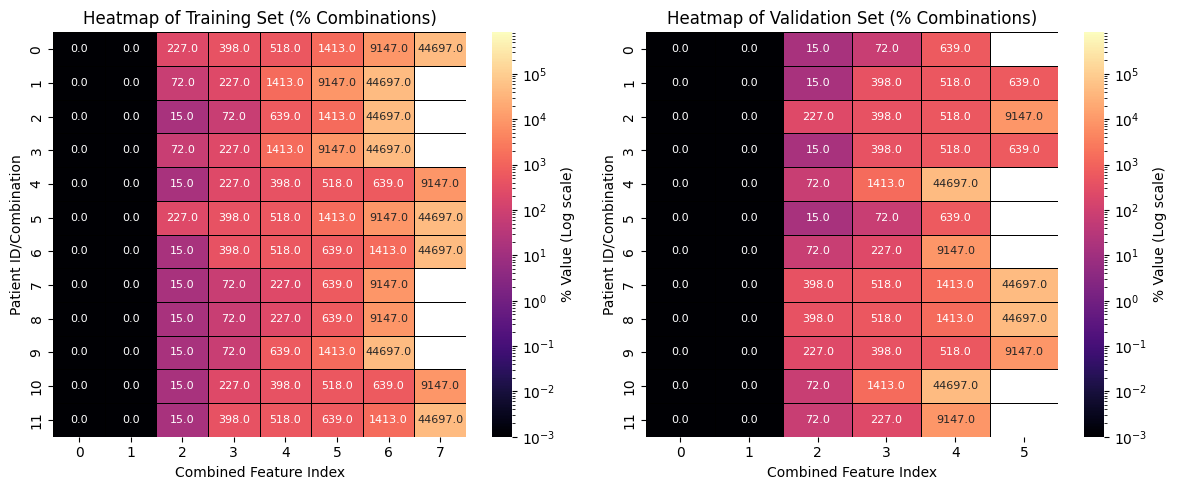

In [74]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

heatmap_fold(train_heat, train_labels, multiple_donations, ax = ax1, tot_blast_num_list= tot_blast_num_list)
heatmap_fold(val_heat, val_labels, multiple_donations, ax = ax2, fold = 'valid', tot_blast_num_list= tot_blast_num_list)
# Opzionale: Regola gli spazi tra i subplot per evitare sovrapposizioni
plt.tight_layout()
#plt.savefig('a')
# Mostra la figura unica
plt.show()


[0.0, 0.31, 0.21, 0.0, 1.44, 0.01, 27.79, 0.28] [13, 7, 7, 7, 6, 6, 9, 9]
num_list: [0, 518, 398, 0, 9147, 227, 44697, 1413]
num_list_ordered: [    0     0   227   398   518  1413  9147 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 1.000e-02 2.100e-01 3.100e-01 2.800e-01 1.440e+00
 2.779e+01]
[0.0, 0.03, 0.0, 1.44, 0.01, 27.79, 0.28] [15, 3, 3, 6, 6, 9, 9]
num_list: [0, 72, 0, 9147, 227, 44697, 1413]
num_list_ordered: [    0     0    72   227  1413  9147 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697], [0, 0, 72, 227, 1413, 9147, 44697]]
[0.000e+00 0.000e+00 3.000e-02 1.000e-02 2.800e-01 1.440e+00 2.779e+01]
[0.0, 0.03, 0.0, 0.15, 0.0, 27.79, 0.28] [15, 3, 3, 12, 12, 9, 9]
num_list: [0, 72, 0, 639, 15, 44697, 1413]
num_list_ordered: [    0     0    15    72   639  1413 44697]
[[0, 0, 227, 398, 518, 1413, 9147, 44697], [0, 0, 72, 227, 1413, 9147, 44697], [0, 0, 15, 72, 639, 1413, 44697]]
[ 0.    0.    0.    0.03  0.15  0.28 27.79]
[0.0, 0.03, 0.0, 1.44, 0.01, 2

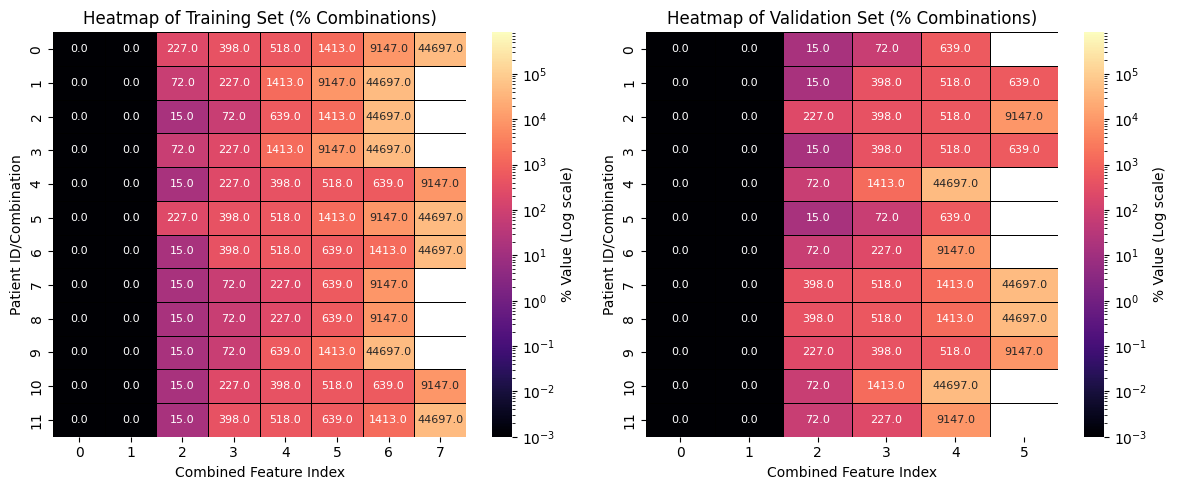

In [75]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

heatmap_fold(train_heat, train_labels, multiple_donations, ax = ax1, tot_blast_num_list= tot_blast_num_list)
heatmap_fold(val_heat, val_labels, multiple_donations, ax = ax2, fold = 'valid', tot_blast_num_list= tot_blast_num_list)
# Opzionale: Regola gli spazi tra i subplot per evitare sovrapposizioni
plt.tight_layout()
#plt.savefig('a')
# Mostra la figura unica
plt.show()
